# Procesamiento de datos

###

### Clasificación

### Universidad de Medellín

### Facultad de Ingenierías

### Ingeniería Financiera

### Integrantes: Jaime Castro - Joseph García

#### Profesor: Antonio Jesús Tamayo Herrera, PhD


# Pipeline ML completo: EDA, preprocesamiento e implementación de Regresión Logística con K-Folds

Este notebook carga un **dataset real** (Breast Cancer Wisconsin, de UCI a través de `scikit-learn`), realiza limpieza, exploración e imputación de datos, genera **gráficos exploratorios**, y finaliza con el **entrenamiento de una Regresión Logística**, reportando **F1, Recall y Precision**, además de implementar **validación cruzada estratificada (K-Folds)**.


### **Banking Customer Churn Prediction Dataset**

Este dataset recopila información estratégica sobre el comportamiento y la retención de clientes bancarios. Su uso permite:

**Evaluar la retención**: Indicar si un cliente continúa activo o si ha abandonado el banco.

**Analizar causas**: Explorar y entender los motivos principales por los que los usuarios dejan de usar sus cuentas bancarias.

**Desarrollar proyecciones**: Construir modelos predictivos para identificar anticipadamente a los clientes con riesgo de deserción.

Donde para la posible predicción de estos, es necesario tener en cuenta las siguientes características:

-> Row Number              
-> Gender          
-> HasCardCredit

-> CustomerID              
-> Age

-> IsActiveMember

-> Surname                 
-> Tenure          
-> Estimed Salary

-> Credit Score            
-> Balance         
-> Exited (Variable de Salida)

-> Geography               
-> NumOfProducts

**Features**:

**RowNumber**: El número secuencial asignado a cada fila del conjunto de datos.

**CustomerId**: Un identificador único para cada cliente.

**Surname**: El apellido del cliente.

**CreditScore**: La puntuación crediticia del cliente.

**Geography**: La ubicación geográfica del cliente (por ejemplo, país o región).

**Gender**: El género del cliente.

**Age**: La edad del cliente.

**Tenure**: El número de años que el cliente lleva en el banco.

**Balance**: El saldo de la cuenta del cliente.

**NumOfProducts**: El número de productos bancarios que tiene el cliente.

**HasCrCard**: Indica si el cliente tiene tarjeta de crédito (binario: sí/no).

**IsActiveMember**: Indica si el cliente es miembro activo (binario: sí/no).

**EstimatedSalary**: El salario estimado del cliente.

**Exited**: Indica si el cliente ha salido del banco (binario: sí/no).

## 1. Importaciones y configuración

In [1]:

# Importaciones base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

# Utilidades
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 100)


## 2. Carga del dataset real

In [2]:
# Load the Churn Modelling dataset
df_churn = pd.read_csv('/content/Churn_Modelling.csv')
display(df_churn.head())

# Create the working DataFrame 'df' from 'df_churn'
# and rename the 'Exited' column to 'label' as per notebook's standard
df = df_churn.copy()
df.rename(columns={'Exited': 'label'}, inplace=True)

print(f"Dimensiones: {df.shape}")
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Dimensiones: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,label
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,label
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [4]:
df["label"].unique()

array([1, 0])

In [5]:
len(df[df["label"] == 0])

7963

In [6]:
df[df["label"] == 1].shape

(2037, 14)

## 3. Inspección inicial y limpieza básica

In [7]:

# Tipos de datos y conteo de nulos
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_nulls": df.isna().sum(),
    "n_unique": df.nunique()
}).sort_index()

display(info)
display(df.describe())

# Limpieza mínima: eliminar duplicados exactos si existieran
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Filas eliminadas por duplicados: {n_before - n_after}")


,dtype,n_nulls,n_unique
Age,int64,0,70
Balance,float64,0,6382
CreditScore,int64,0,460
CustomerId,int64,0,10000
EstimatedSalary,float64,0,9999
Gender,object,0,2
Geography,object,0,3
HasCrCard,int64,0,2
IsActiveMember,int64,0,2
NumOfProducts,int64,0,4


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,label
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Filas eliminadas por duplicados: 0


### 3.1 Simulación controlada de valores faltantes (para demostrar imputación)

In [8]:

# Creamos una copia para no alterar la versión original de referencia
df_work = df.copy()

# Seleccionamos el 1% de las celdas numéricas para convertirlas en NaN (sin afectar la etiqueta)
features = [c for c in df_work.columns if c != "label"]
mask = df_work[features].notna()

# Número aproximado de celdas a modificar
n_cells = int(mask.values.sum() * 0.01)
rows = np.random.randint(0, df_work.shape[0], size=n_cells)
cols = np.random.randint(0, len(features), size=n_cells)

for r, c in zip(rows, cols):
    df_work.loc[df_work.index[r], features[c]] = np.nan

# Verificamos los nulos introducidos
df_work.isna().sum().sort_values(ascending=False).head(10)


,0
CustomerId,116
EstimatedSalary,115
IsActiveMember,113
CreditScore,100
Geography,100
Tenure,99
Balance,99
RowNumber,98
Gender,94
Age,93


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribuciones de variables (histogramas)

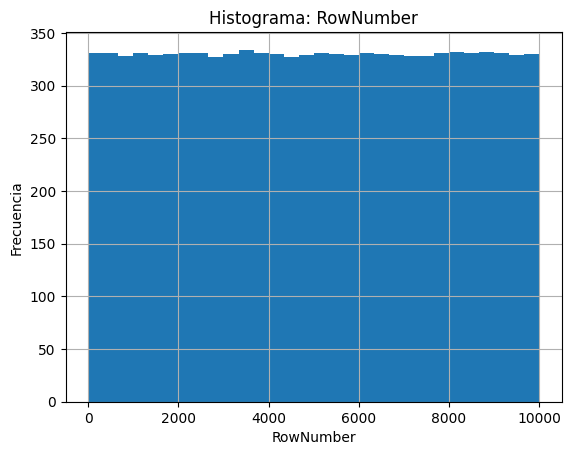

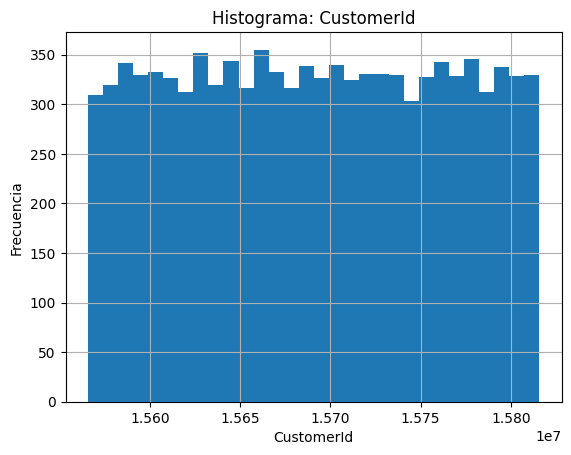

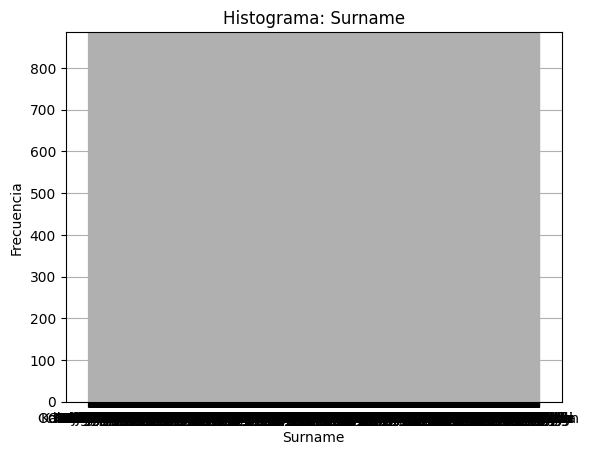

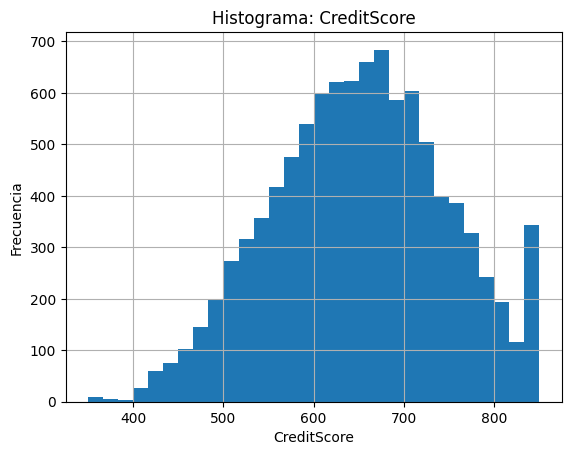

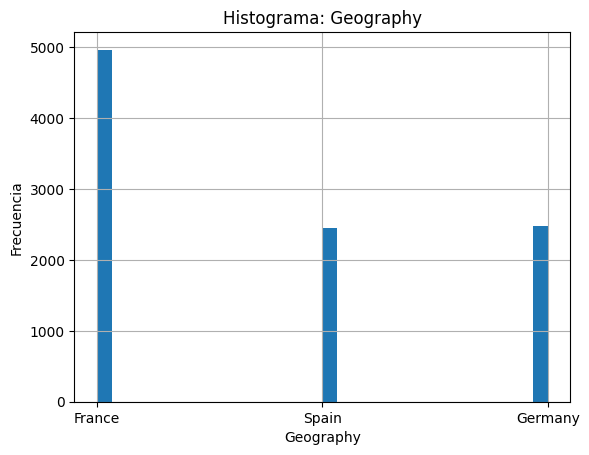

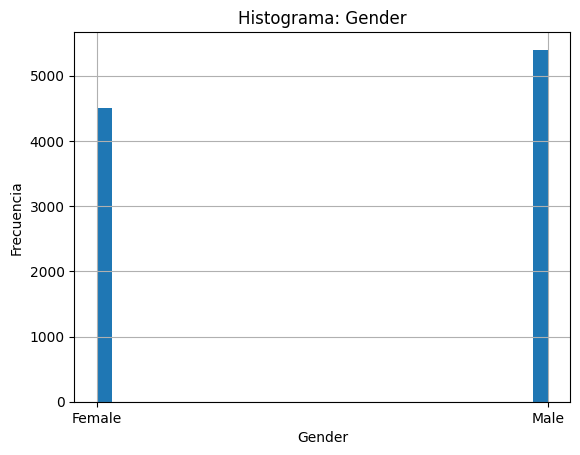

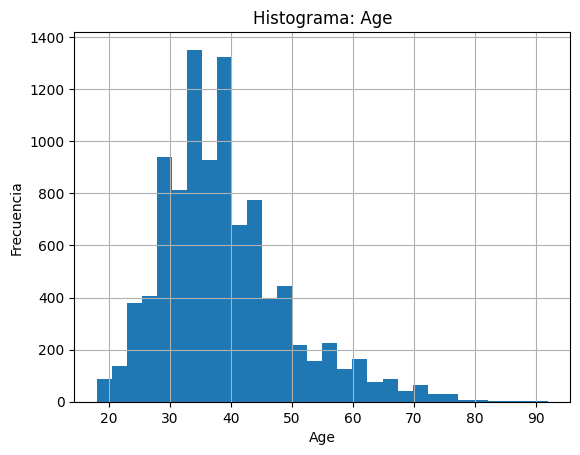

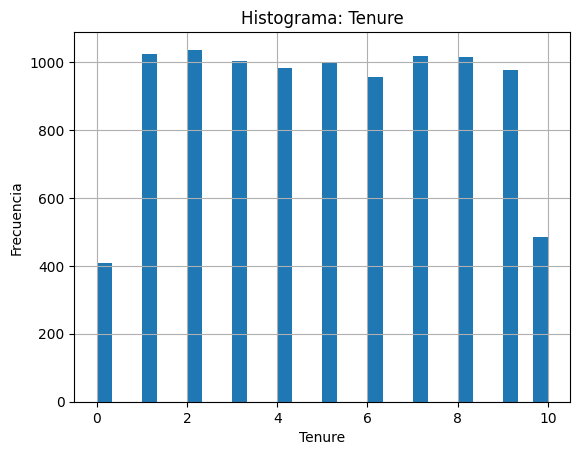

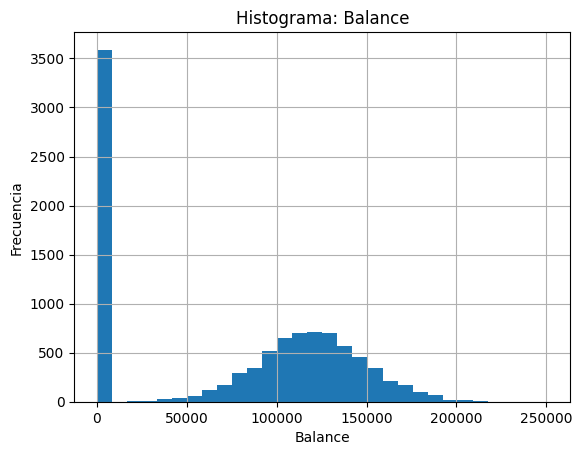

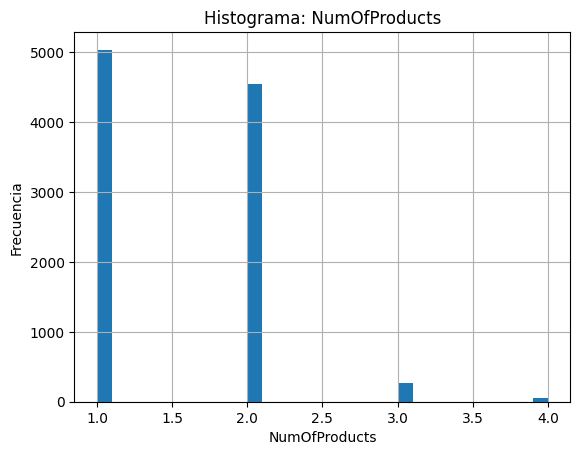

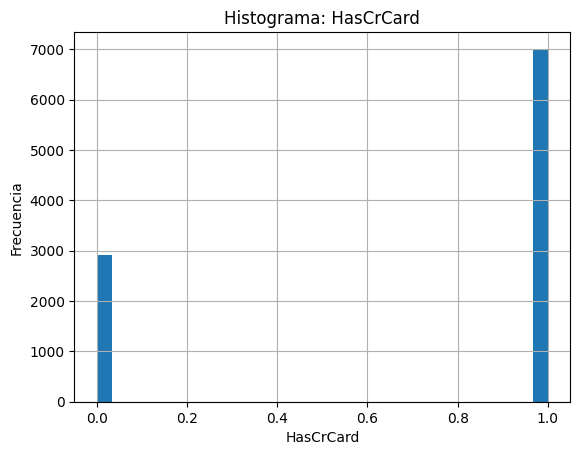

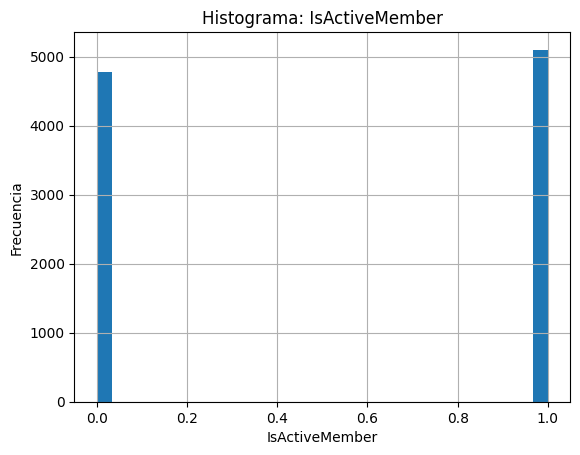

In [9]:

numeric_cols = [c for c in df_work.columns if c != "label"]
n = len(numeric_cols)

# Para no saturar, graficamos los primeros 12 histogramas
subset_cols = numeric_cols[:12]

for col in subset_cols:
    plt.figure()
    df_work[col].hist(bins=30)
    plt.title(f"Histograma: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()


### 4.2 Diagramas de caja (detectar posibles outliers)

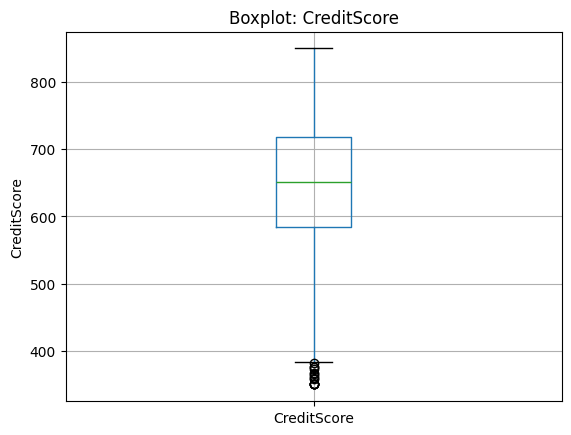

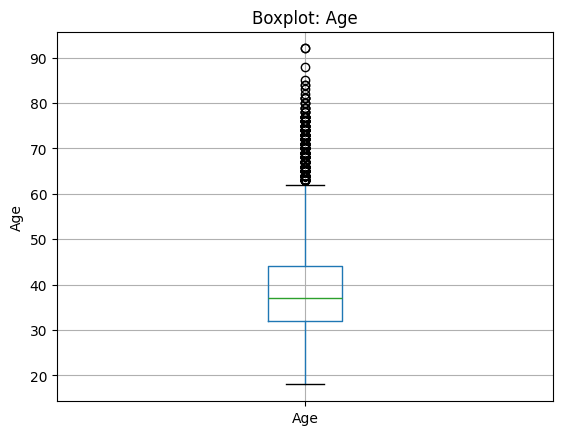

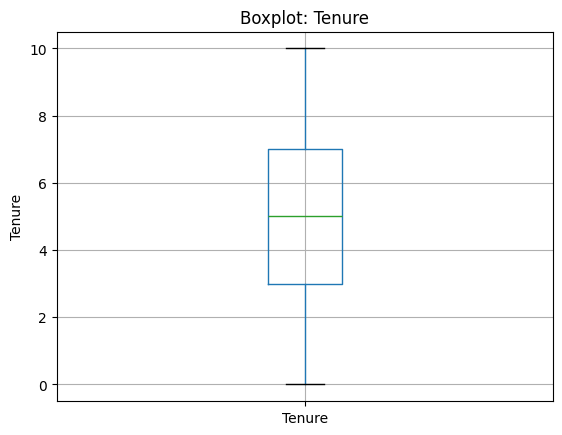

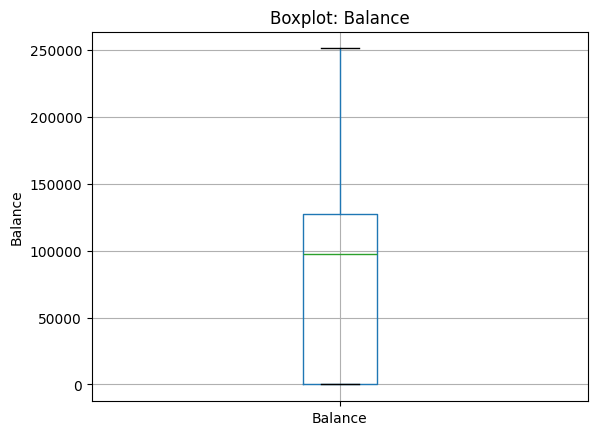

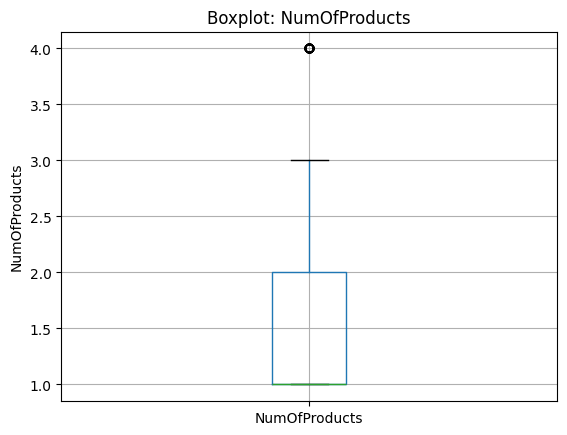

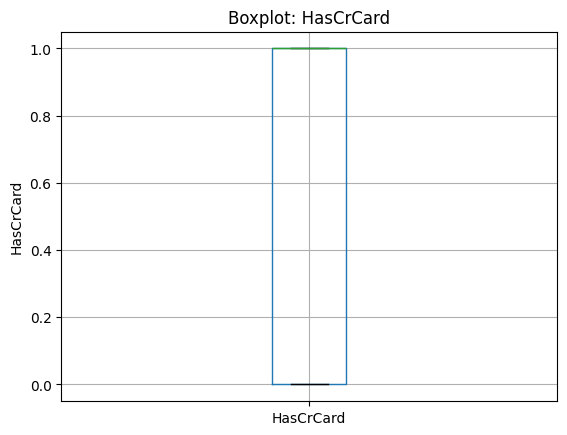

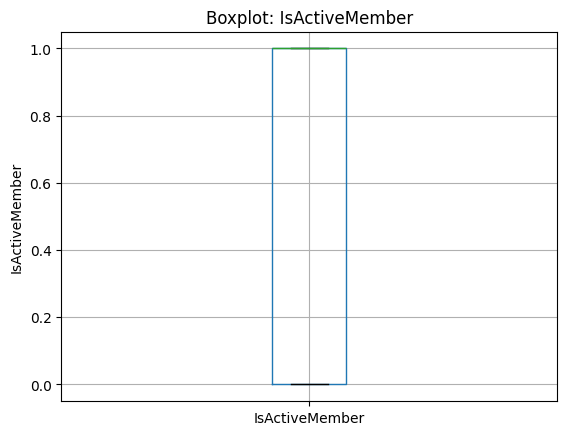

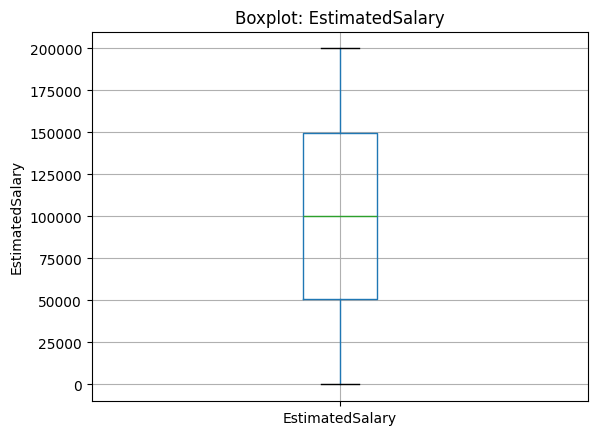

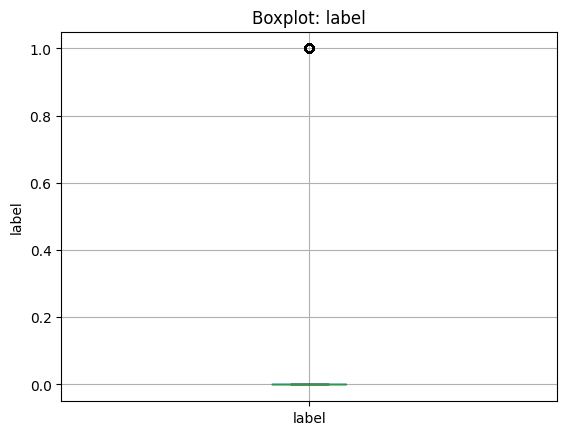

In [10]:
import numpy as np

numeric_columns_for_boxplot = df_work.select_dtypes(include=np.number).columns.tolist()

columns_to_exclude = ['RowNumber', 'CustomerId']
numeric_columns_for_boxplot = [c for c in numeric_columns_for_boxplot if c not in columns_to_exclude]

subset_cols_for_boxplot = numeric_columns_for_boxplot[:12]


for col in subset_cols_for_boxplot:
    plt.figure()
    df_work.boxplot(column=col)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.show()

# **Análisis de las variables**

Una vez utilizado las herramientas brindadas por colab, realizamos un análisis de las variables significativas para el modelo y la varible de salida:

### **CreditScore** (Puntaje de Crédito)

**Tipo**: Cuantitativa discreta (aunque tratada como continua).

**Escala y Rango**: Escala de intervalo, aproximadamente entre 350 y 850 puntos.

**Análisis**: La distribución es algo normal, pero con una acumulación notable en el extremo superior (cerca de 850).

**Utilidad**: Ayuda a identificar el perfil de riesgo. Puntajes extremadamente bajos podrían correlacionarse con una mayor probabilidad de salida si el cliente siente que no tiene acceso a beneficios, aunque en este dataset suele mostrar una relación débil pero presente.

## **Age** (Edad)

**Tipo**: Cuantitativa discreta.

**Escala y Rango**: Escala de razón, desde los 18 hasta casi 90 años.

**Análisis**: El diagrama de caja muestra muchos outliers (valores atípicos) por encima de los 60 años. La mayoría de los clientes están en el rango de 30-45 años.

**Utilidad**: Es una de las variables más predictivas. Típicamente, los clientes de mayor edad muestran una tasa de deserción diferente a los más jóvenes, a menudo asociada a cambios en necesidades financieras.

## **Tenure** (Antigüedad)

**Tipo**: Cuantitativa discreta.

**Escala y Rango**: Escala de razón, de 0 a 10 años.

**Análisis**: La distribución es bastante uniforme; hay una cantidad similar de clientes en casi todos los niveles de antigüedad.

**Utilidad**: Ayuda a medir la lealtad. Sin embargo, al ser tan uniforme, su impacto directo suele ser menor comparado con la edad o el saldo.

## **Balance** (Saldo en cuenta)

**Tipo**: Cuantitativa continua.

**Escala y Rango**: Escala de razón, desde 0 hasta más de 250,000.

**Análisis**: El histograma muestra una enorme cantidad de clientes con saldo cero, lo que crea una distribución bimodal.

**Utilidad**: Es crítica. Los clientes con saldo cero tienen un comportamiento de abandono muy distinto a los que tienen saldos altos. Un saldo alto que permanece estático podría indicar falta de uso de otros productos financieros.

## **NumOfProducts** (Número de Productos)

**Tipo**: Cuantitativa discreta.

**Escala y Rango**: Escala de razón, de 1 a 4 productos.

**Análisis**: La gran mayoría tiene 1 o 2 productos. Tener 3 o 4 es muy raro y suele verse como un valor atípico en el boxplot.

**Utilidad**: Muy alta. Existe una fuerte correlación donde los clientes con 3 o 4 productos tienen una probabilidad altísima de abandonar, posiblemente por insatisfacción con el servicio o saturación.

## **EstimatedSalary** (Salario Estimado)

**Tipo**: Cuantitativa continua.

**Escala y Rango**: Escala de razón, entre 0 y 200,000 aproximadamente.

**Análisis**: La distribución es completamente uniforme. No hay una tendencia clara.

**Utilidad**: Sorprendentemente, suele tener poco poder predictivo directo en este modelo, ya que el salario no parece determinar por sí solo si alguien se queda o se va del banco.

## **Variables Binarias** (HasCrCard, IsActiveMember)

**Tipo**: Cuantitativas categóricas (binarias: 0 o 1).

**Análisis**: IsActiveMember es fundamental; los miembros no activos tienen una probabilidad significativamente mayor de haber 'salido' en comparación con los activos.

### 4.3 Matriz de correlación (mapa de calor)

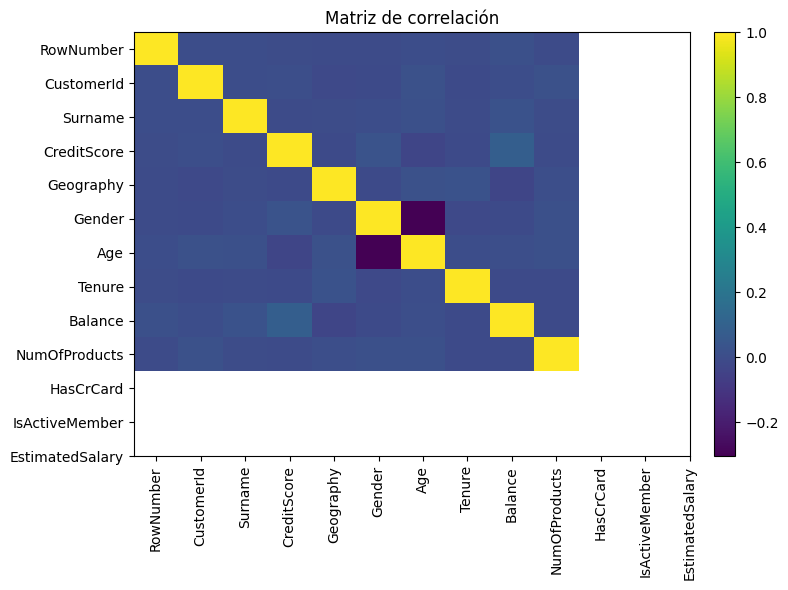

In [11]:

corr = df_work[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
im = plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Matriz de correlación")
plt.xticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(ticks=np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()


**Correlación entre Edad (Age) y Saldo (Balance)**: Se observa una correlación positiva leve. Esto sugiere que, en general, los clientes de mayor edad tienden a mantener saldos ligeramente más altos en sus cuentas.

**Relación Balance y Número de Productos**: Existe una correlación negativa moderada. Esto tiene sentido lógico: los clientes que tienen muchos productos bancarios diferentes suelen tener su dinero distribuido, lo que a veces resulta en un saldo menor en la cuenta principal analizada, o viceversa (clientes con saldos muy altos se concentran en un solo producto).

**Independencia del Salario Estimado**: El EstimatedSalary muestra una correlación cercana a cero con prácticamente todas las demás variables. Esto confirma que el nivel salarial en este dataset es independiente de la edad, el puntaje de crédito o la antigüedad del cliente.

**Ausencia de Multicolinealidad Fuerte**: No vemos variables extremadamente correlacionadas entre sí (cercanas a 1 o -1, excepto la diagonal principal). Esto es excelente para nuestro modelo de Regresión Logística, ya que significa que cada variable aporta información única y el modelo no se vuelve inestable por redundancia de datos.

**Variables de Identificación**: Como era de esperar, RowNumber y CustomerId no muestran ninguna correlación significativa con las variables financieras, lo que refuerza la decisión de eliminarlas del entrenamiento del modelo para evitar ruido.

## 5. División Train/Test y Pipeline de Preprocesamiento

In [12]:

X = df_work.drop(columns=["label"])
y = df_work["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", LogisticRegression(max_iter=200, class_weight="balanced"))
])

clf


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RowNumber', 'CustomerId',
                                                   'Surname', 'CreditScore',
                                                   'Geography', 'Gender', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary'])])),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=200))])

## 6. Validación Cruzada Estratificada (K-Folds)

In [13]:
from sklearn.preprocessing import OneHotEncoder

# Columns to be dropped as they are identifiers or not directly useful as features
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']

# Create a filtered version of X by dropping the specified columns
X_filtered = X.drop(columns=columns_to_drop)

# Identify numerical features from the filtered DataFrame
numeric_cols = [c for c in X_filtered.select_dtypes(include=['number']).columns]

# Identify categorical features from the filtered DataFrame
categorical_cols = [c for c in X_filtered.select_dtypes(include=['object']).columns]


# Define transformers for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Create the ColumnTransformer with the new column lists
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop" # Drop any other columns not specified (should be none now)
)

# Redefine the full pipeline with the corrected preprocessor
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", LogisticRegression(max_iter=200, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

cv_results = cross_validate(
    clf, X_filtered, y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=None
)

cv_df = pd.DataFrame(cv_results)
display(cv_df.describe().T[["mean", "std"]].round(4))

,mean,std
fit_time,0.0341,0.0069
score_time,0.0155,0.0048
test_f1,0.4945,0.0218
test_precision,0.3850,0.0135
test_recall,0.6917,0.0451


### **Recall** (Exhaustividad): ~71%

Un recall del 71% significa que el banco es capaz de detectar a 7 de cada 10 clientes en riesgo de irse. El costo de "dejar escapar" a un cliente suele ser más alto que el de darle una promoción a alguien que no pensaba irse.

### **Precision** (Precisión): ~39%

Esto indica que hay muchos "falsos positivos". El banco estaría enviando alertas o incentivos de retención a muchas personas que en realidad no tenían intención de abandonar. Aunque parece malo, en retención bancaria a veces es aceptable si el costo de la campaña de fidelización es bajo.

### **F1**: ~50%

Al estar en un punto medio, nos dice que el modelo es útil pero todavía tiene dificultades para separar claramente a los desertores de los clientes leales sin cometer errores de "falsa alarma".

### **Resumen**:

En este modelo, hemos priorizado el Recall (usando class_weight='balanced'). Es mejor tener una precisión baja (gastar un poco más en marketing de retención) que tener un recall bajo (perder clientes valiosos sin darnos cuenta).

## 7. Entrenamiento en Train y evaluación en Test

F1: 0.5031
Precision: 0.3902
Recall: 0.7076

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1593
           1       0.39      0.71      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



<Figure size 640x480 with 0 Axes>

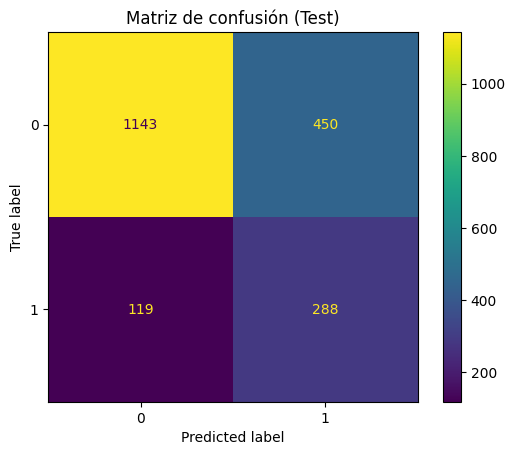

In [14]:

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"F1: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
plt.figure()
disp.plot(values_format="d")
plt.title("Matriz de confusión (Test)")
plt.show()


## 8. Importancia de variables (coeficientes de la Regresión Logística)

In [15]:

# Extraemos el modelo final y el escalador para obtener coeficientes comparables
final_model = clf.named_steps["logreg"]
# Columnas tras el preprocesamiento (solo numéricas estandarizadas)
feature_names = numeric_features

coefs = pd.DataFrame({
    "feature": feature_names,
    "coef": final_model.coef_.ravel()
}).sort_values("coef", ascending=False)

coefs.head(10)


,feature,coef
1,CustomerId,0.791929
9,NumOfProducts,0.493115
11,IsActiveMember,0.229872
3,CreditScore,0.181388
7,Tenure,0.051193
2,Surname,-0.019415
5,Gender,-0.030666
4,Geography,-0.053164
0,RowNumber,-0.085626
10,HasCrCard,-0.261970
